In [10]:
%matplotlib inline

In [11]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import backtrader as bt
import datetime
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
class MyBuySell(bt.observers.BuySell):
    plotlines = dict(
        buy=dict(marker='^', markersize=8.0, color='blue', fillstyle='full'),
        sell=dict(marker='v', markersize=8.0, color='red', fillstyle='full')
    )

In [20]:
class BBand_Strategy(bt.Strategy):
    params = (('period', 20),
              ('devfactor', 2.0),)

    def __init__(self):
        
        #시가(open)/종가(close) 추적
        self.data_open = self.datas[0].open
        self.data_close = self.datas[0].close
        
        #주문(order)/주가(price)/수수료(comm) 추적
        self.order = None
        self.price = None
        self.comm = None

        #볼린저 밴드 추가 매수/매도 신호 추적
        self.b_band = bt.ind.BollingerBands(self.datas[0], period=self.p.period, devfactor=self.p.devfactor)
        self.buy_signal = bt.ind.CrossOver(self.datas[0], self.b_band.lines.bot)
        self.sell_signal = bt.ind.CrossOver(self.datas[0], self.b_band.lines.top)

    def log(self, txt):
        '''Logging function'''
        dt = self.datas[0].datetime.date(0).isoformat()
        print(f'{dt}, {txt}')

    # 주문(Order)의 상태가 바뀌었을 때 호출하는 함수
    def notify_order(self, order):
        
        if order.status in [order.Submitted, order.Accepted]:  #Submitted(주문제출), Accepted(주문접수)는 실제로 거래가 이루어진 것이 아니기에 return
            return

        if order.status in [order.Completed]:                  #Completed(거래체결)
            if order.isbuy():
                self.log(
                    f'매수 주문 완료 --- 주문가(Price): {order.executed.price:.2f}, 거래가(Cost): {order.executed.value:.2f}, 수수료(Commission): {order.executed.comm:.2f}'
                )
                self.price = order.executed.price
                self.comm = order.executed.comm
            else:
                self.log(
                    f'매도 주문 완료 --- 주문가(Price): {order.executed.price:.2f}, 거래가(Cost): {order.executed.value:.2f}, 수수료(Commission): {order.executed.comm:.2f}'
                )

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:    #Canceled(주문취소), Margin(자금부족), Rejected(주문거부)
            self.log(f'주문 실패 확인 --- 사유: {order.getstatusname()}')

        self.order = None

    #거래(Trade)가 끝났을 때 그 거래의 손익을 알려주는 함수
    def notify_trade(self, trade):
        if not trade.isclosed:
            return

        self.log(f'거래 결과 확인 --- 거래수익(Gross): {trade.pnl:.2f}, 순수익(Net): {trade.pnlcomm:.2f}')

    #다음 거래 봉이 시작되는 시점의 오픈가격을 활용해서 #매매 판단 및 주문을 수행
    def next_open(self):
        
        if not self.position:          #주식을 보유하지 않은 경우(매수)
            if self.buy_signal > 0:
               
                size = int(self.broker.getcash() / self.datas[0].open)
               
                self.log(f'매수 주문 생성 --- 수량(Size): {size}, 주문가능평가(Cash): {self.broker.getcash():.2f}, 주식시가(Open): {self.data_open[0]:.2f}, 주식종가(Close): {self.data_close[0]:.2f}')
                self.buy(size=size)
        else:                         #주식을 보유한 경우(매도)
            if self.sell_signal < 0:
               
                self.log(f'매도 주문 생성 --- 수량(Size): {self.position.size}')
                self.sell(size=self.position.size)

### 백테스트용 데이터 불러오기(마이크로소프트 2018년도)

In [21]:
dir_nm = "dailyStock"
target = "MSFT"
file_path = f"{dir_nm}/{target}.csv"

msft_df = pd.read_csv(file_path, encoding="utf-8")
msft_df['Date'] = pd.to_datetime(msft_df['Date'])
msft_df = msft_df.set_index("Date")

msft_df = msft_df.loc["2018-01-01":"2018-12-31"]

data = bt.feeds.PandasData(dataname=msft_df)

### 백테스트 설정

In [22]:
cerebro = bt.Cerebro(stdstats = False, cheat_on_open=True)

cerebro.addstrategy(BBand_Strategy)
cerebro.adddata(data)
cerebro.broker.setcash(10000.0)
cerebro.broker.setcommission(commission=0.001)
cerebro.addobserver(MyBuySell)
cerebro.addobserver(bt.observers.Value)
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
cerebro.addanalyzer(bt.analyzers.TimeReturn, _name='time_return')

### 백테스트 수행

In [23]:
print('포트폴리오 시작가: %.2f' % cerebro.broker.getvalue())
backtest_result = cerebro.run()
print('포트폴리오 종료가: %.2f' % cerebro.broker.getvalue())

포트폴리오 시작가: 10000.00
2018-02-12, 매수 주문 생성 --- 수량(Size): 112, 주문가능평가(Cash): 10000.00, 주식시가(Open): 88.74, 주식종가(Close): 89.13
2018-02-12, 매수 계약 체결 --- 체결가(Price): 88.74, 거래가(Cost): 9938.88, 수수료(Commission): 9.94
2018-04-19, 매도 주문 생성 --- 수량(Size): 112
2018-04-19, 매도 계약 체결 --- 체결가(Price): 96.44, 거래가(Cost): 9938.88, 수수료(Commission): 10.80
2018-04-19, 거래 결과 확인 --- 거래수익(Gross): 862.40, 순수익(Net): 841.66
2018-06-29, 매수 주문 생성 --- 수량(Size): 109, 주문가능평가(Cash): 10841.66, 주식시가(Open): 98.93, 주식종가(Close): 98.61
2018-06-29, 매수 계약 체결 --- 체결가(Price): 98.93, 거래가(Cost): 10783.37, 수수료(Commission): 10.78
2018-07-17, 매도 주문 생성 --- 수량(Size): 109
2018-07-17, 매도 계약 체결 --- 체결가(Price): 104.61, 거래가(Cost): 10783.37, 수수료(Commission): 11.40
2018-07-17, 거래 결과 확인 --- 거래수익(Gross): 619.12, 순수익(Net): 596.93
2018-10-15, 매수 주문 생성 --- 수량(Size): 105, 주문가능평가(Cash): 11438.59, 주식시가(Open): 108.91, 주식종가(Close): 107.60
2018-10-15, 주문 실패 확인 --- 사유: Margin
2018-10-26, 매수 주문 생성 --- 수량(Size): 108, 주문가능평가(Cash): 11438.59, 주식시가(Open): 105.69

### 백테스트 결과 도식화

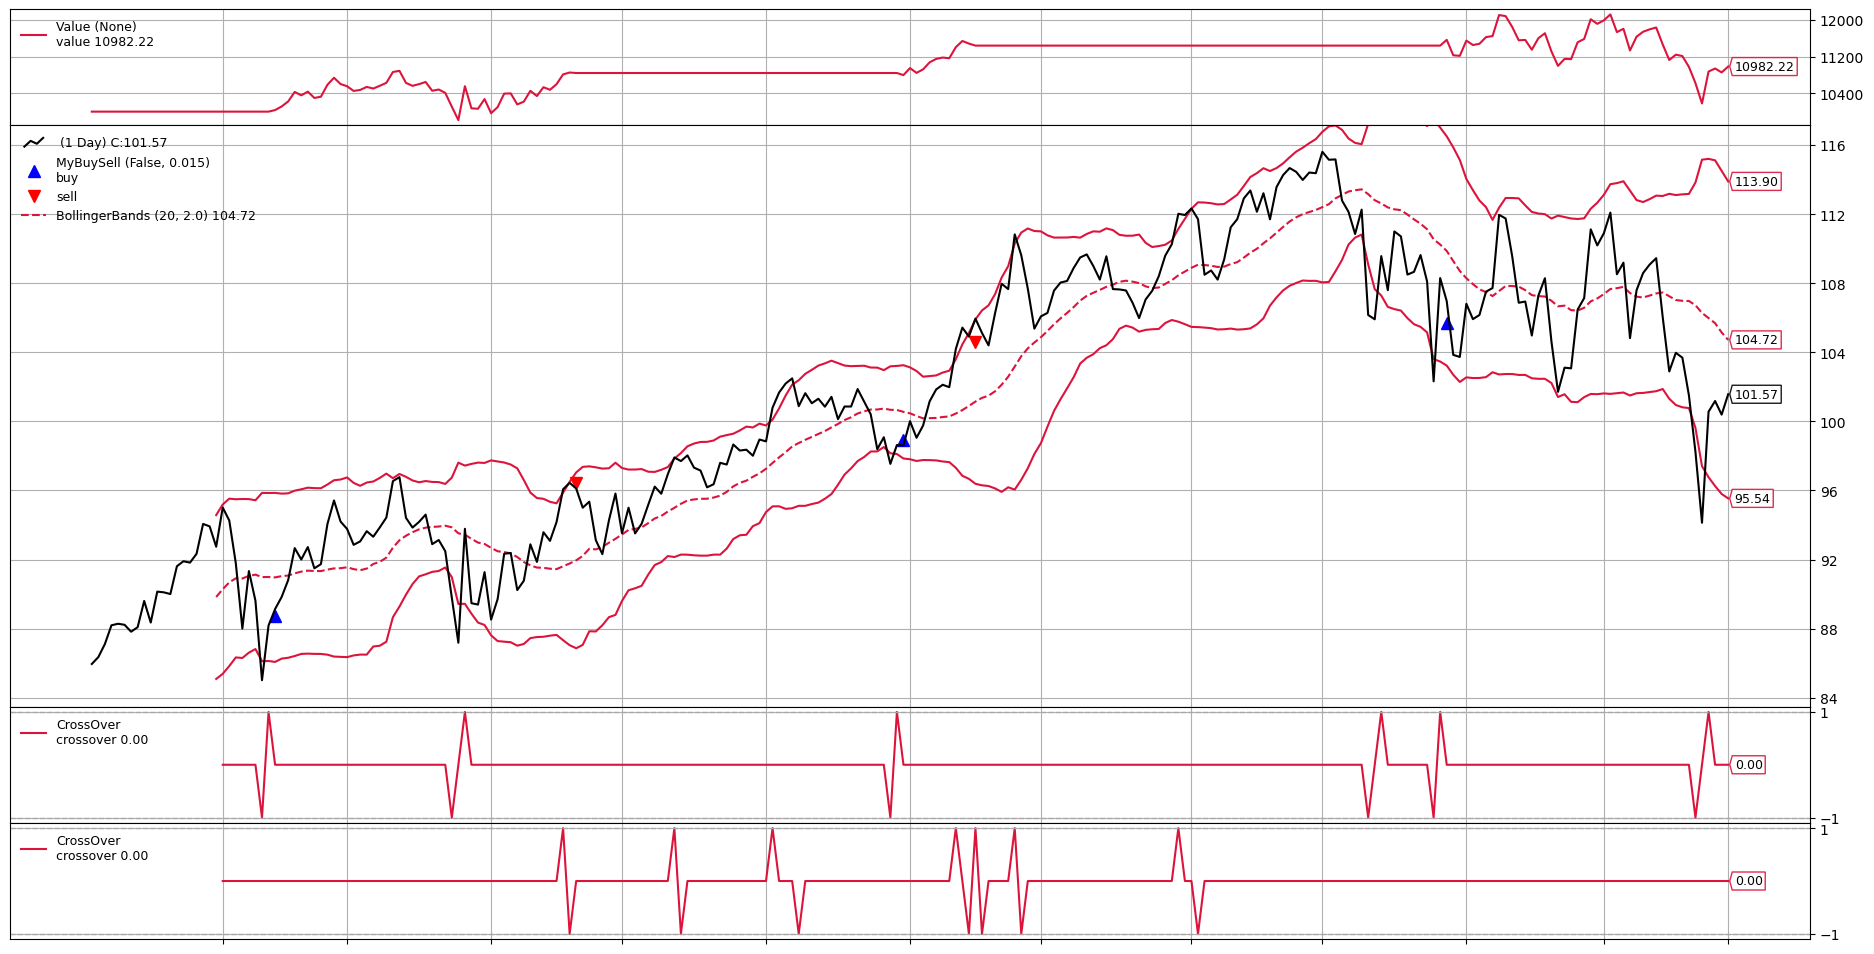

[[<Figure size 2000x1000 with 4 Axes>]]

In [25]:
plt.rcParams['figure.figsize'] = (20, 10)

cerebro.plot(iplot=False, 
             volume=False, 
             use='module://matplotlib_inline.backend_inline')

### 백테스트 결과 분석

In [31]:
returns = backtest_result[0].analyzers.returns.get_analysis()

print("전체 누적 로그 수익률:", f"{returns['rtot']:.6f}")
print("평균 로그 수익률:", f"{returns['ravg']:.6f}")
print("연환산 수익률:", f"{returns['rnorm']:.6f}")
print("연환산 수익률(%):", f"{returns['rnorm100']:.2f}")

전체 누적 로그 수익률: 0.093692
평균 로그 수익률: 0.000373
연환산 수익률: 0.098632
연환산 수익률(%): 9.86


### 일별 포트폴리오 수익률

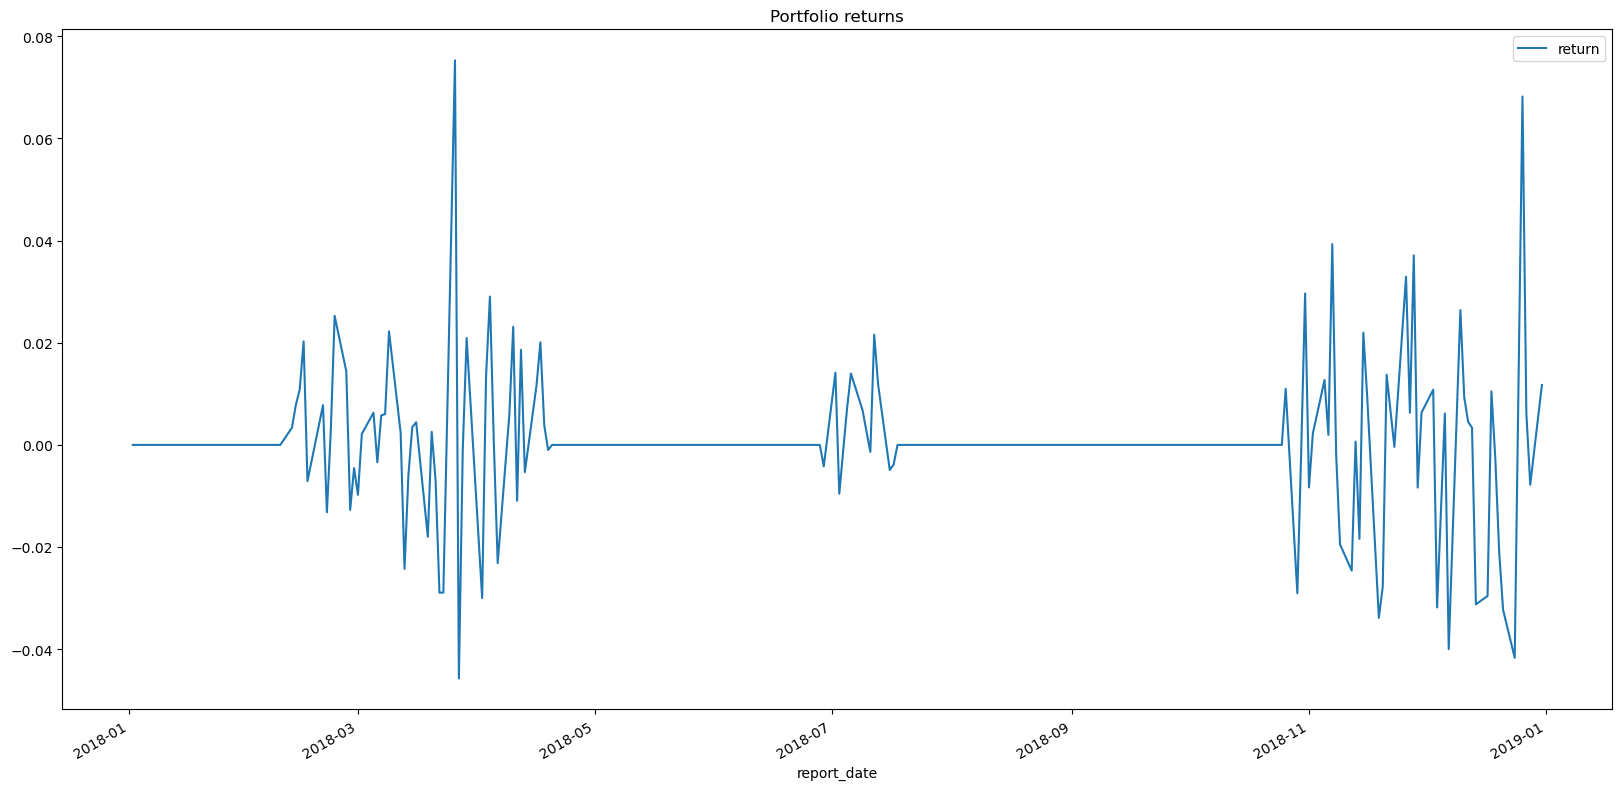

In [34]:
returns_dict = backtest_result[0].analyzers.time_return.get_analysis()

returns_df = pd.DataFrame(list(returns_dict.items()), columns = ['report_date', 'return']).set_index('report_date')

returns_df.plot(title="Portfolio returns")

plt.show()